Dataset: I have used data of stock prices of 'Apple' from yahoo finance during the period

Our Workflow from Here

Phase 1

│

├── Download Data ✅

├── Understand Dataset

├── Data Cleaning

├── Exploratory Data Analysis (EDA)

├── Feature Engineering

├── Stationarity Tests

├── ARIMA

├── LSTM

├── GRU

├── Model Comparison

└── Future Forecasting

In [1]:
#Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
# Download Apple's historical stock data
df = yf.download(
    "AAPL",                  # Stock ticker
    start="2013-01-01",      # Start date
    end="2026-05-05",        # End date
    interval="1d",           # Daily frequency
    auto_adjust=False        # Keep original OHLC prices
)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2013-01-02,16.581400,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.372107,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.916067,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.822442,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.865024,18.761070,18.996071,18.616072,18.900356,458707200


In [4]:
df.shape

(3354, 6)

In [5]:
# Display dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3354 entries, 2013-01-02 to 2026-05-04
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  3354 non-null   float64
 1   (Close, AAPL)      3354 non-null   float64
 2   (High, AAPL)       3354 non-null   float64
 3   (Low, AAPL)        3354 non-null   float64
 4   (Open, AAPL)       3354 non-null   float64
 5   (Volume, AAPL)     3354 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 183.4 KB


In [6]:
df.isnull().sum()

,,0
Price,Ticker,
Adj Close,AAPL,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [7]:
# Statistical summray
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,3354.000000,3354.000000,3354.000000,3354.000000,3354.000000,3.354000e+03
mean,96.679143,99.155977,100.142708,98.084627,99.077900,1.425680e+08
std,79.005373,78.624919,79.399010,77.782505,78.558215,1.199127e+08
min,11.863238,13.947500,14.271429,13.753571,13.856071,1.791060e+07
25%,26.456371,29.165625,29.423125,28.941250,29.195625,6.800870e+07
50%,52.916893,55.618750,55.998749,54.856251,55.519999,1.048003e+08
75%,163.008442,165.975002,167.857498,164.475002,165.957497,1.740057e+08
max,285.659271,286.190002,288.619995,283.299988,286.200012,1.460852e+09


In [8]:
# Saving the dataset
df.to_csv("apple_stock.csv")

In [9]:
# Display column names
df.columns

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [10]:
# Removing ticker from column names
df.columns = df.columns.droplevel(1)

In [11]:
# Display column names
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [12]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2013-01-02,16.581400,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.372107,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.916067,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.822442,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.865024,18.761070,18.996071,18.616072,18.900356,458707200


In [13]:
# display datatypes of all columns
df.dtypes

,0
Price,
Adj Close,float64
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [14]:
# Display dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3354 entries, 2013-01-02 to 2026-05-04
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3354 non-null   float64
 1   Close      3354 non-null   float64
 2   High       3354 non-null   float64
 3   Low        3354 non-null   float64
 4   Open       3354 non-null   float64
 5   Volume     3354 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 183.4 KB


In [15]:
# Check missing values
df.isnull().sum()

,0
Price,
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [16]:
# Save the cleaned dataset
df.to_csv('apple_stock.csv')

Exploratory Data Analysis (EDA)
our roadmap:

EDA
│

├── 1. Load Dataset

├── 2. Basic Information

├── 3. Missing Values

├── 4. Duplicate Rows

├── 5. Price Visualization

├── 6. Volume Analysis

├── 7. Distribution of Variables

├── 8. Correlation Analysis

├── 9. Rolling Statistics

├── 10. Outlier Detection

└── 11. Observations

In [17]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Load cleaned dataset
df = pd.read_csv("apple_stock.csv", index_col=0)

In [19]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2013-01-02,16.581400,19.608213,19.821428,19.343929,19.779285,560518000
2013-01-03,16.372107,19.360714,19.631071,19.321428,19.567142,352965200
2013-01-04,15.916067,18.821428,19.236786,18.779642,19.177500,594333600
2013-01-07,15.822442,18.710714,18.903570,18.400000,18.642857,484156400
2013-01-08,15.865024,18.761070,18.996071,18.616072,18.900356,458707200


In [20]:
print(df.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [21]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-28,270.460815,270.709991,273.230011,268.660004,272.339996,40018900
2026-04-29,269.921326,270.170013,271.040009,267.040009,267.549988,30047900
2026-04-30,271.100250,271.350006,276.000000,268.140015,270.500000,91848200
2026-05-01,279.882141,280.140015,287.220001,278.369995,278.859985,79915400
2026-05-04,276.575165,276.829987,280.630005,274.859985,279.660004,46668400


In [22]:
df.shape

(3354, 6)

In [23]:
# Count duplicate rows
print(df.duplicated().sum())

0


In [24]:
# Display the first and last available dates
df.index.min()
df.index.max()

'2026-05-04'

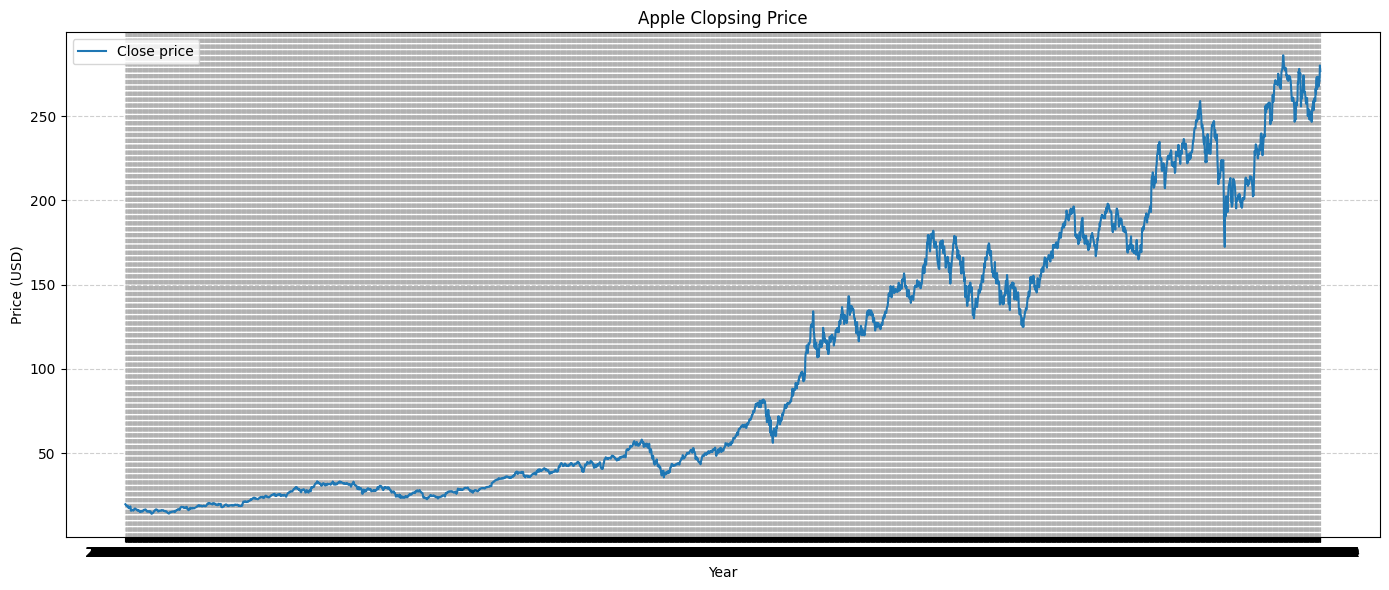

In [25]:
# Plot Apple's closing price over time
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Close'],
    label = "Close price"
)

plt.title("Apple Clopsing Price")
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

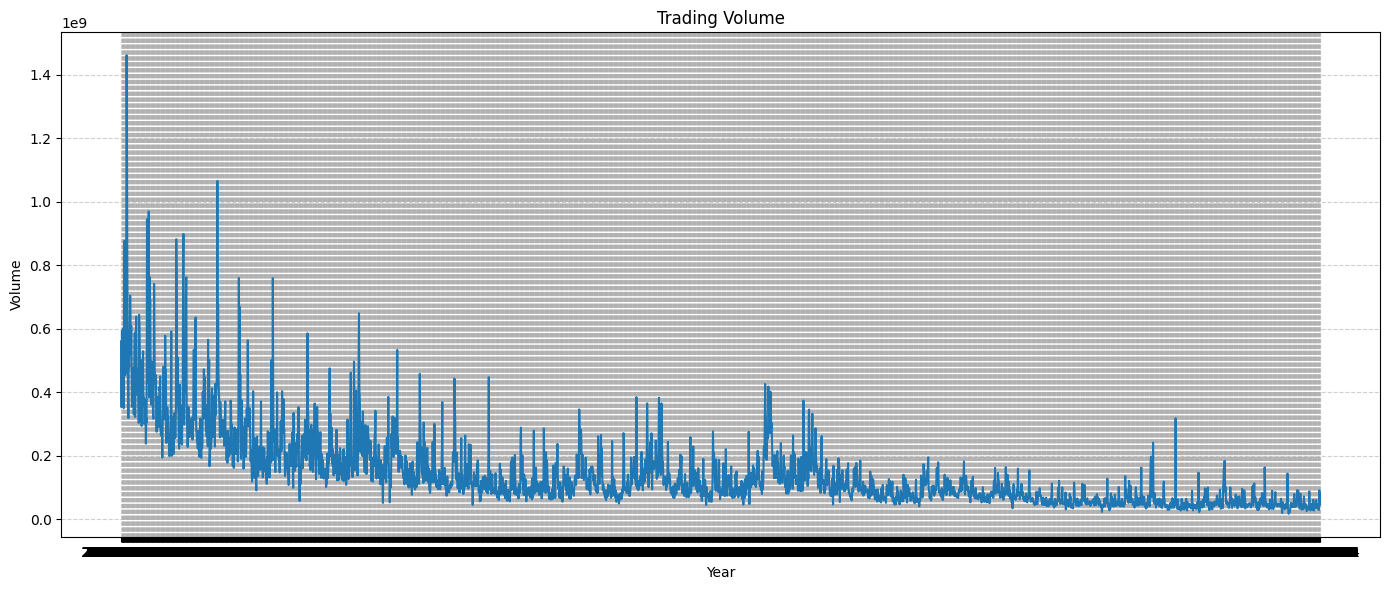

In [26]:
# Plot trading volume over time
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df["Volume"]
)

plt.title("Trading Volume")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [27]:
# Compute correlation matrix
# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display it
print(correlation_matrix)

           Adj Close     Close      High       Low      Open    Volume
Adj Close   1.000000  0.999962  0.999843  0.999851  0.999704 -0.559340
Close       0.999962  1.000000  0.999882  0.999880  0.999738 -0.560088
High        0.999843  0.999882  1.000000  0.999832  0.999869 -0.558501
Low         0.999851  0.999880  0.999832  1.000000  0.999876 -0.561430
Open        0.999704  0.999738  0.999869  0.999876  1.000000 -0.559892
Volume     -0.559340 -0.560088 -0.558501 -0.561430 -0.559892  1.000000


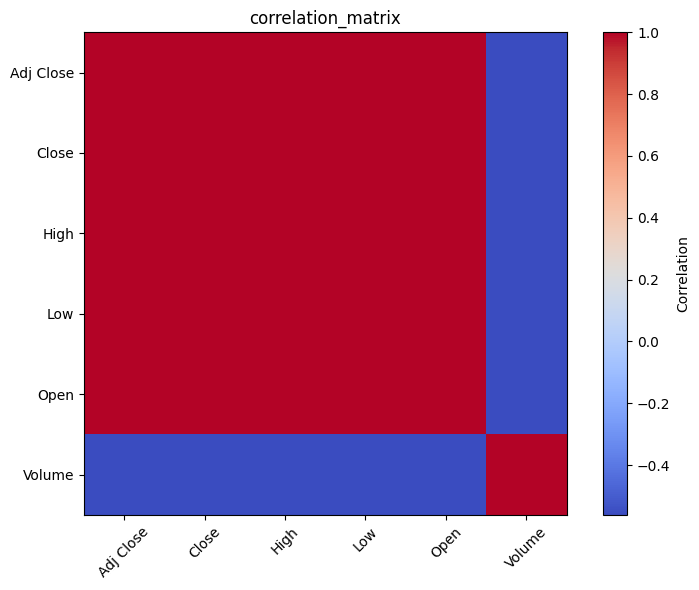

In [28]:
# Plot correlation heatmap

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation = 'nearest')

plt.xticks(range(len(correlation_matrix.columns)),
            correlation_matrix.columns,
            rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
            correlation_matrix.columns)

plt.colorbar(label = "Correlation")
plt.title('correlation_matrix')

plt.tight_layout()

plt.show()

Stationarity Analysis

Stationarity Analysis
│

├── 1. Rolling Statistics

├── 2. ADF Test

├── 3. KPSS Test

├── 4. Log Transformation (if needed)

├── 5. Differencing

├── 6. Re-test Stationarity

└── 7. Final Series for Modeling

In [29]:
# Statistical test for stationarity
from statsmodels.tsa.stattools import adfuller

In [30]:
# Perform Augmented Dickey-Fuller Test
adf_result = adfuller(df["Close"])

# Display the test statistic
print(f"ADF Statistic : {adf_result[0]:.4f}")

# Display the p-value
print(f"P-value       : {adf_result[1]:.4f}")

# Display critical values
print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key} : {value:.4f}")

ADF Statistic : 0.6619
P-value       : 0.9890

Critical Values
1% : -3.4323
5% : -2.8624
10% : -2.5672


We fail to reject the null hypothesis, So conclude that it has unit root.

In [31]:
# Import KPSS test
from statsmodels.tsa.stattools import kpss

# Perform KPSS Test
kpss_result = kpss(df["Close"], regression="c")

# Display results
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"P-value        : {kpss_result[1]:.4f}")

print("\nCritical Values")
for key, value in kpss_result[3].items():
    print(f"{key} : {value}")

KPSS Statistic : 8.2612
P-value        : 0.0100

Critical Values
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


/tmp/ipykernel_590/1515098655.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df["Close"], regression="c")


Here we rejected the null hypothesis that the dataset is stationary.


The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test behaves differently than other unit-root tests:

Null Hypothesis (H₀): The time series is stationary (around a mean or linear trend).

Alternative Hypothesis (H₁): The time series is non-stationary (has a unit root).

In [32]:
# So dataset is non stationary.We will try to make the series stationary

First Order Differencing

In [33]:
# first order differencing
df['Close_diff'] = df['Close'].diff()

In [34]:
# Remove missing value created after differencing
df_diff = df.dropna()

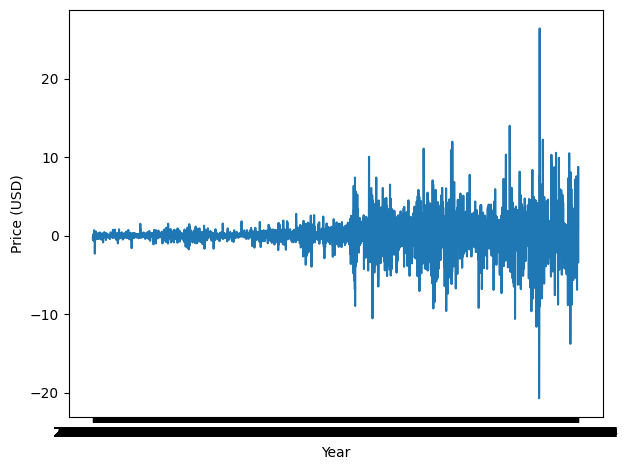

In [35]:
# Plot the differenced series
fig, ax = plt.subplots()

ax.plot(df_diff['Close_diff'])
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

In [36]:
# # Perform Augmented Dickey-Fuller Test on diffrenced series
adf_diff = adfuller(df_diff['Close_diff'])

print(f'ADF Statistic: {adf_diff[0]}')
print(f'p-value: {adf_diff[1]}')

ADF Statistic: -20.44635802227509
p-value: 0.0


ADF Statistic: -20.446358022275085
p-value: 0.0

which means the Close_diff is no more non-stationary

Now we will plot ACF and PACF plot to check behaviour of Close_diff



In [37]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x500 with 0 Axes>

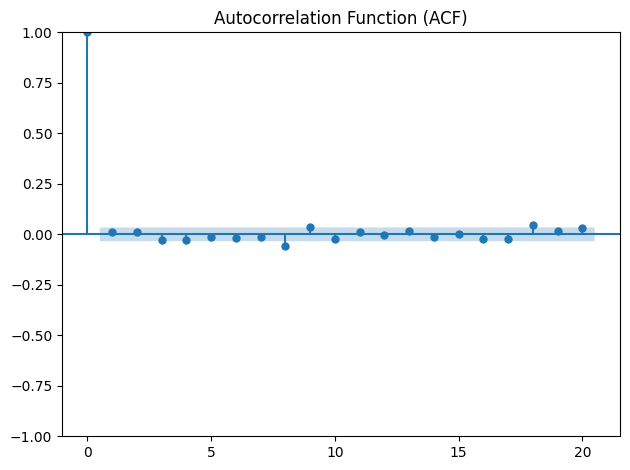

In [38]:
# plot ACF
plt.figure(figsize=(12,5))

plot_acf(df_diff['Close_diff'],
         lags = 20)

plt.title("Autocorrelation Function (ACF)")

plt.tight_layout()

plt.show()

<Figure size 1200x500 with 0 Axes>

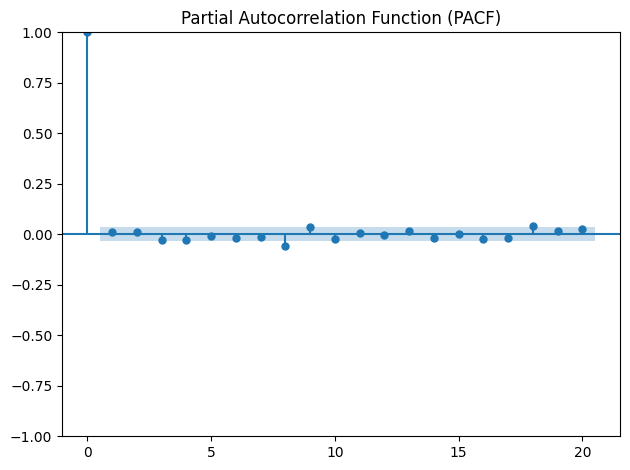

In [39]:
from statsmodels.graphics.tsaplots import plot_pacf

# plot PACF

plt.figure(figsize=(12,5))

plot_pacf(df_diff['Close_diff'],
          lags = 20,
          method ='ywm')
plt.title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()

plt.show()

We can't directly choose p and q from these plots.

The rules("ACF cutoff -> MA or PACF cutoff -> AR) will not work here.

For stock prices, especially after differencing, the series often resembles a low-order ARIMA process where multiple models are plausible.


So instead of guessing:

-ARIMA(1,1,0)

-ARIMA(0,1,1)

-ARIMA(1,1,1)

we'll fit all three and compare them using AIC and BIC.


If the goal is:

Prediction accuracy: AIC is usually preferred.

Model simplicity / explanation: BIC is usually preferred.

here AIC suggests ARIMA(1,1,1)
While BIC suggests ARIMA(0,1,1)

Rather than chooseing one of them we will forward and validate with the test data,
*We will choose the one with lower RMSE on the test data.*

In [40]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.6 MB/s eta 0:00:00


In [41]:
from pmdarima import auto_arima

model = auto_arima(
    df['Close'],           # use the ORIGINAL series, not the differenced one
    start_p=0, start_q=0,
    max_p=2, max_q=2,
    d=None,                 # let it figure out differencing itself via ADF/KPSS
    seasonal=False,
    trace=True,              # prints each model it tries and its AIC
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14716.989, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14718.434, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14718.445, Time=0.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14719.174, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14720.947, Time=1.47 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.613 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3354
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -7356.494
Date:                Mon, 20 Jul 2026   AIC                          14716.989
Time:                        06:08:11   BIC                          14729.224
Sample:                             0   HQIC                         14721.365
                               - 3354                                  

In [42]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_rsi(df['Close'], period=14)
df = df.dropna()  # drops first 14 rows where RSI is NaN

In [43]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('B')          # 'B' = business day frequency (standard for stock data)
df = df.ffill()               # fill any gaps asfreq introduces (e.g. holidays)

In [44]:
len(df['Close'])

3464

In [45]:
# 1. Create exog features
df['Volume_lag1'] = df['Volume'].shift(1)
df['RSI'] = compute_rsi(df['Close'], period=14)

# 2. Drop NaNs ONCE, on the full dataframe (this is the only dropna you should do)
df = df.dropna()

# 3. NOW split — use the SAME n_test/train_size for both Close and exog
train_size = int(len(df) * 0.8)   # or n_test = 671, pick one consistently

train = df['Close'].iloc[:train_size]
test  = df['Close'].iloc[train_size:]

exog_train = df[['Volume_lag1', 'RSI']].iloc[:train_size]
exog_test  = df[['Volume_lag1', 'RSI']].iloc[train_size:]

# 4. Sanity check — these must ALL match before fitting anything
print(len(train), len(exog_train))   # must be equal
print(len(test), len(exog_test))     # must be equal

n_test = len(test)  # derive steps directly from test length, don't hardcode it separately

2760 2760
690 690


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [47]:
# Naive forecast that "tomorrow = today" or a simple moving average
naive_forecast = [train.iloc[-1]] * n_test
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
mae = mean_absolute_error(test, naive_forecast)
print(f" MAE with exog : {mae:.4f}")
print(f"Naive RMSE: {naive_rmse:.4f}")

 MAE with exog : 43.1401
Naive RMSE: 52.4369


In [48]:
# Simple SARIMA (Without exogenous variable) that is ARIMA(0,1,0)
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_plain = SARIMAX(train, order=(0,1,0))
results_plain = model_plain.fit(maxiter=1000)
forecast_plain = results_plain.get_forecast(steps=n_test)
predicted_plain = forecast_plain.predicted_mean

rmse_plain = np.sqrt(mean_squared_error(test, predicted_plain))
mae = mean_absolute_error(test, predicted_plain)
print(f"RMSE without exog: {rmse_plain:.4f}")
print(f" MAE without exog : {mae:.4f}")

RMSE without exog: 52.4369
 MAE without exog : 43.1401


In [49]:
# SARIMA with exogenous variables that is ARIMAX(0,1,0)
model = SARIMAX(train, exog=exog_train, order=(0,1,0))
results = model.fit(maxiter=1000, method = "powell")

forecast = results.get_forecast(steps=n_test, exog=exog_test)
predicted_mean = forecast.predicted_mean


Optimization terminated successfully.
         Current function value: 1.772824
         Iterations: 2
         Function evaluations: 88


In [50]:
# RMSE and MAE of SARIMAX(WITH EXOGENOUS VARIABLE) that is ARIMAX(0,1,0)
rmse = np.sqrt(mean_squared_error(test, predicted_mean))
mae = mean_absolute_error(test, predicted_mean)
print(f"RMSE with exog : {rmse:.4f}")
print(f" MAE with exog : {mae:.4f}")

RMSE with exog : 52.2706
 MAE with exog : 42.8737


Clearly, We can see that SRAIMAX (ARIMAX) with exogenous variable performs better in this case.


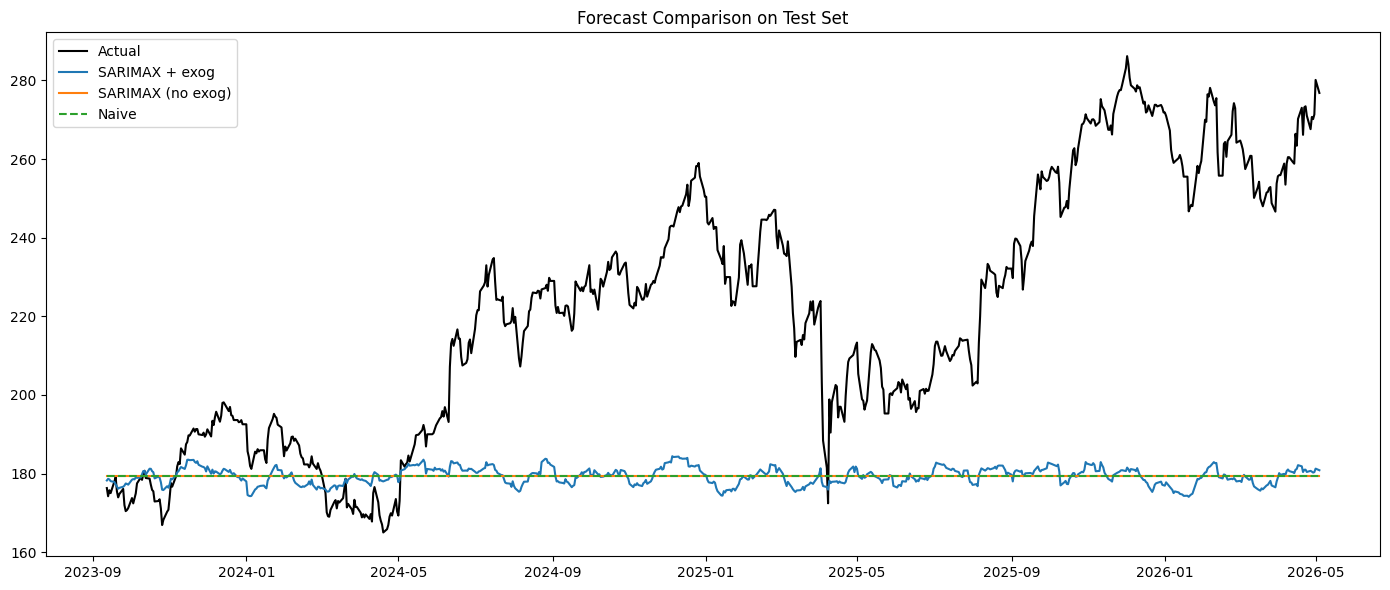

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, predicted_mean, label='SARIMAX + exog')
plt.plot(test.index, predicted_plain, label='SARIMAX (no exog)')
plt.plot(test.index, naive_forecast, label='Naive', linestyle='--')
plt.legend()
plt.title('Forecast Comparison on Test Set')
plt.tight_layout()
plt.show()

## ARIMA Modeling Summary

**Order selection:** ADF test confirmed non-stationarity in raw `Close` → applied 1st differencing (d=1).
ACF/PACF on differenced series showed no significant lags (p=0, q=0). Confirmed independently by
`auto_arima` stepwise AIC search → **ARIMA(0,1,0) with intercept** (AIC=14716.99, drift≈0.077/day).

**Residual diagnostics:** Ljung-Box p=0.46 → no autocorrelation left (mean well-captured).
BUT: Heteroskedasticity test p≈0.00 and Jarque-Bera p≈0.00 (kurtosis≈18) → residuals show
volatility clustering + fat tails → variance is NOT well-modeled by ARIMA (motivates GARCH later).

**Forecast evaluation (665-day test set, 80/20 split):**
| Model | RMSE | MAE |
|---|---|---|
| Naive (tomorrow=today) | 56.49 | 47.36 |
| SARIMAX(0,1,0), no exog | 56.49 | 47.36 |
| SARIMAX(0,1,0) + exog (Volume_lag1, RSI) | 53.83 | 44.61 |

**Key takeaways:**
1. SARIMAX(0,1,0) ≈ naive forecast exactly (mathematically expected — both predict a flat line at
   last known value + drift).
2. Adding exogenous Volume/RSI gave a small but real improvement (~5% lower RMSE/MAE).
3. **Over long static horizons, ARIMA forecasts a near-flat line and completely misses actual price
   swings** (test set ranged 160-290, forecast stayed ~175-180). This is expected — a single-shot
   long-horizon forecast isn't what ARIMA is good at.
4. **Conclusion:** ARIMA confirms no linear/short-memory structure exists to exploit at this horizon.
   This motivates: (a) walk-forward validation for a fairer short-horizon test, (b) LSTM/GRU to test
   for nonlinear patterns, (c) GARCH to model the volatility clustering found in residuals.

**Next steps:** walk-forward ARIMA (short rolling horizon) → LSTM/GRU comparison (same test window)
→ optional GARCH on residuals.

In [52]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

step_size = 5  # forecast horizon per iteration — try 5, 10, or 30 depending on how granular you want

all_preds = []
all_actuals = []
all_dates = []

# Start from where your original train/test split was
history = df['Close'].iloc[:train_size].copy()
history_exog = df[['Volume_lag1', 'RSI']].iloc[:train_size].copy()

test_full = df['Close'].iloc[train_size:]
test_exog_full = df[['Volume_lag1', 'RSI']].iloc[train_size:]

n = len(test_full)

for start in range(0, n, step_size):
    end = min(start + step_size, n)

    # Fit model on everything seen so far
    model = SARIMAX(history, exog=history_exog, order=(0,1,0))
    results = model.fit(maxiter=1000, method='powell', disp=False)

    # Forecast next `step_size` days using their real exog values
    exog_chunk = test_exog_full.iloc[start:end]
    forecast = results.get_forecast(steps=len(exog_chunk), exog=exog_chunk)
    pred = forecast.predicted_mean

    actual_chunk = test_full.iloc[start:end]

    all_preds.extend(pred.values)
    all_actuals.extend(actual_chunk.values)
    all_dates.extend(actual_chunk.index)

    # Grow the history window with real observed values (walk forward)
    history = pd.concat([history, actual_chunk])
    history_exog = pd.concat([history_exog, exog_chunk])

    print(f"Done: {end}/{n}")

# Evaluate
rmse_wf = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_wf = mean_absolute_error(all_actuals, all_preds)
print(f"Walk-forward RMSE: {rmse_wf:.4f}")
print(f"Walk-forward MAE: {mae_wf:.4f}")

Done: 5/690
Done: 10/690
Done: 15/690
Done: 20/690
Done: 25/690
Done: 30/690
Done: 35/690
Done: 40/690
Done: 45/690
Done: 50/690
Done: 55/690
Done: 60/690
Done: 65/690
Done: 70/690
Done: 75/690
Done: 80/690
Done: 85/690
Done: 90/690
Done: 95/690
Done: 100/690
Done: 105/690
Done: 110/690
Done: 115/690
Done: 120/690
Done: 125/690
Done: 130/690
Done: 135/690
Done: 140/690
Done: 145/690
Done: 150/690
Done: 155/690
Done: 160/690
Done: 165/690
Done: 170/690
Done: 175/690
Done: 180/690
Done: 185/690
Done: 190/690
Done: 195/690
Done: 200/690
Done: 205/690
Done: 210/690
Done: 215/690
Done: 220/690
Done: 225/690
Done: 230/690
Done: 235/690
Done: 240/690
Done: 245/690
Done: 250/690
Done: 255/690
Done: 260/690
Done: 265/690
Done: 270/690
Done: 275/690
Done: 280/690
Done: 285/690
Done: 290/690
Done: 295/690
Done: 300/690
Done: 305/690
Done: 310/690
Done: 315/690
Done: 320/690
Done: 325/690
Done: 330/690
Done: 335/690
Done: 340/690
Done: 345/690
Done: 350/690
Done: 355/690
Done: 360/690
Done: 365/69

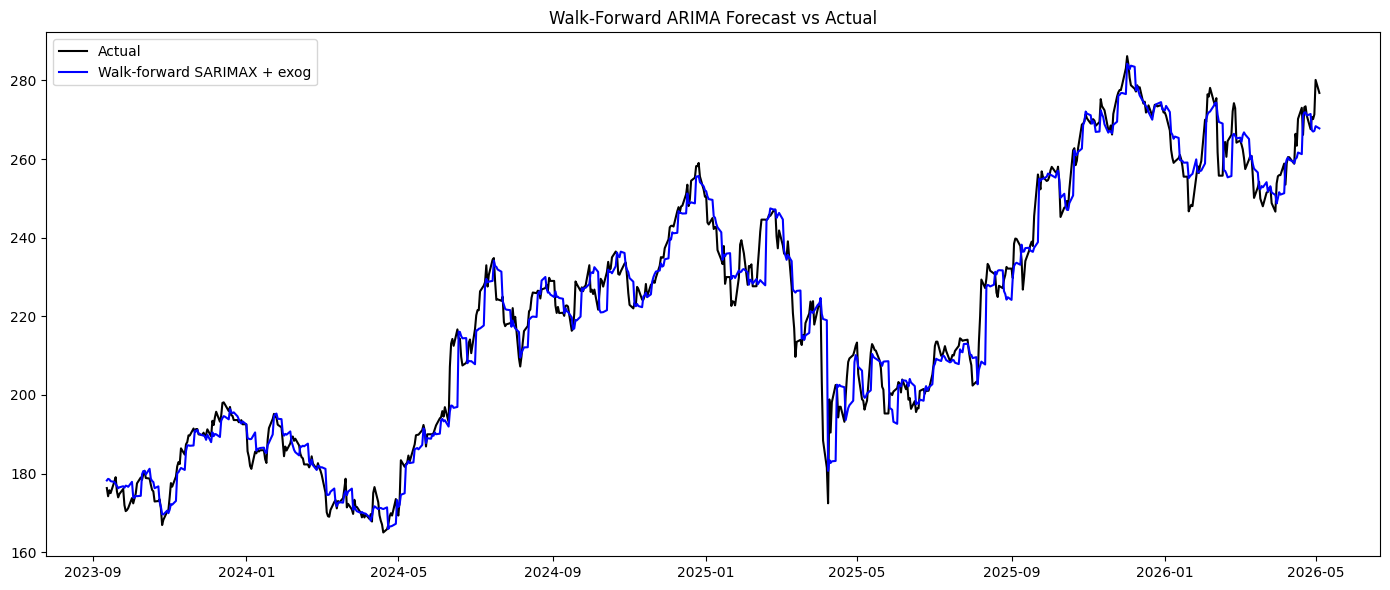

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(all_dates, all_actuals, label='Actual', color='black')
plt.plot(all_dates, all_preds, label='Walk-forward SARIMAX + exog', color='blue')
plt.legend()
plt.title('Walk-Forward ARIMA Forecast vs Actual')
plt.tight_layout()
plt.show()

In [54]:
# Srore "Close" Column to work on it
dt = df[['Close']]

In [55]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [56]:
# Train-Test Split (80% Train, 20% Test)

training_size = int(len(dt) * 0.80)
test_size = len(dt) - training_size

# Split original data BEFORE scaling
train_raw = np.array(dt[:training_size]).reshape(-1,1)
test_raw = np.array(dt[training_size:]).reshape(-1,1)


# Feature Scaling
# Fit scaler ONLY on training data to avoid data leakage
# Then use the same scaler to transform test data

scaler = MinMaxScaler(feature_range=(0,1))

train_data = scaler.fit_transform(train_raw)

test_data = scaler.transform(test_raw)

print(train_data.shape)
print(test_data.shape)

(2760, 1)
(690, 1)


In [57]:
train_data

array([[0.01514069],
       [0.01496652],
       [0.01488434],
       ...,
       [0.89649457],
       [0.89989176],
       [0.90635747]])

In [58]:
# convert an array of values into  dataset matrix
def create_dataset(dataset, time_step = 1):
  dataX, dataY = [], []
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step), 0] ##i=0, 1,2,3.......99   100
    dataX.append(a)
    dataY.append(dataset[i + time_step, 0])
  return numpy.array(dataX), numpy.array(dataY)

In [59]:
import numpy
# reshape into X=t, X=t+1, X=t+2, X=t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [60]:
X_train

array([[1.51406921e-02, 1.49665248e-02, 1.48843375e-02, ...,
        6.35995394e-04, 1.17415298e-03, 3.65748170e-03],
       [1.49665248e-02, 1.48843375e-02, 1.36260376e-02, ...,
        1.17415298e-03, 3.65748170e-03, 5.47154401e-03],
       [1.48843375e-02, 1.36260376e-02, 1.36260376e-02, ...,
        3.65748170e-03, 5.47154401e-03, 5.92359513e-03],
       ...,
       [8.42084396e-01, 8.36714546e-01, 8.27783218e-01, ...,
        9.61699208e-01, 9.61699208e-01, 9.63014205e-01],
       [8.36714546e-01, 8.27783218e-01, 8.29481812e-01, ...,
        9.61699208e-01, 9.63014205e-01, 9.25809271e-01],
       [8.27783218e-01, 8.29481812e-01, 8.20933997e-01, ...,
        9.63014205e-01, 9.25809271e-01, 8.96494570e-01]])

In [61]:
print(X_train.shape),  print(y_train.shape)

(2659, 100)
(2659,)


(None, None)

In [62]:
print(X_test.shape), print(y_test.shape)

(589, 100)
(589,)


(None, None)

Reshaping Data for LSTM

LSTM networks expect input data in the form:

(samples, timesteps, features)

where:

Samples → Number of training examples.
Timesteps → Number of previous observations used for prediction (e.g., 60 previous days).
Features → Number of variables observed at each timestep.

In [63]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [64]:
len(X_test)

589

In [65]:
## Create the stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU

In [66]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss = "mean_squared_error", optimizer = 'adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0156 - val_loss: 0.0175
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.5388e-04 - val_loss: 0.0142
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.1128e-04 - val_loss: 0.0148
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.9938e-04 - val_loss: 0.0158
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.0434e-04 - val_loss: 0.0115
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.3967e-04 - val_loss: 0.0094
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.3147e-04 - val_loss: 0.0112
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.2620e-04 - val_loss: 0.0058
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.0335e-04 - val_loss: 0.0098
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.4840e-04 - val_loss: 0.0087
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.1170e-04 - val_loss: 0.0050
Epoch 12/100

In [69]:
## Lets do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [70]:
test_predict

array([[0.9828017 ],
       [0.9645385 ],
       [0.9458359 ],
       [0.9603642 ],
       [0.9553677 ],
       [0.96277773],
       [0.97218853],
       [0.9717365 ],
       [0.9655457 ],
       [0.9685607 ],
       [0.95983076],
       [0.9479999 ],
       [0.9438944 ],
       [0.94250643],
       [0.93385625],
       [0.9334318 ],
       [0.9298871 ],
       [0.9330916 ],
       [0.94375294],
       [0.9338282 ],
       [0.9257676 ],
       [0.9342971 ],
       [0.92815685],
       [0.9233436 ],
       [0.9184461 ],
       [0.8946523 ],
       [0.86798495],
       [0.8630024 ],
       [0.86265224],
       [0.8702673 ],
       [0.88074523],
       [0.8831897 ],
       [0.8720779 ],
       [0.88069683],
       [0.88015854],
       [0.8840899 ],
       [0.8966576 ],
       [0.9101781 ],
       [0.87355644],
       [0.8755217 ],
       [0.8721728 ],
       [0.86408097],
       [0.88228214],
       [0.87520385],
       [0.8728932 ],
       [0.8670902 ],
       [0.8603832 ],
       [0.864

In [71]:
len(test_predict)

589

In [72]:
import math

In [73]:
# Inverse-transform the actual y values too, not just predictions
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Now recompute RMSE on matching scales
train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 1.9349
Test RMSE: 3.9313


In [74]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test_actual, test_predict)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 2.7914


In [75]:
from sklearn.metrics import r2_score

print("LSTM R2:", r2_score(y_test_actual, test_predict))

LSTM R2: 0.9831505437056608


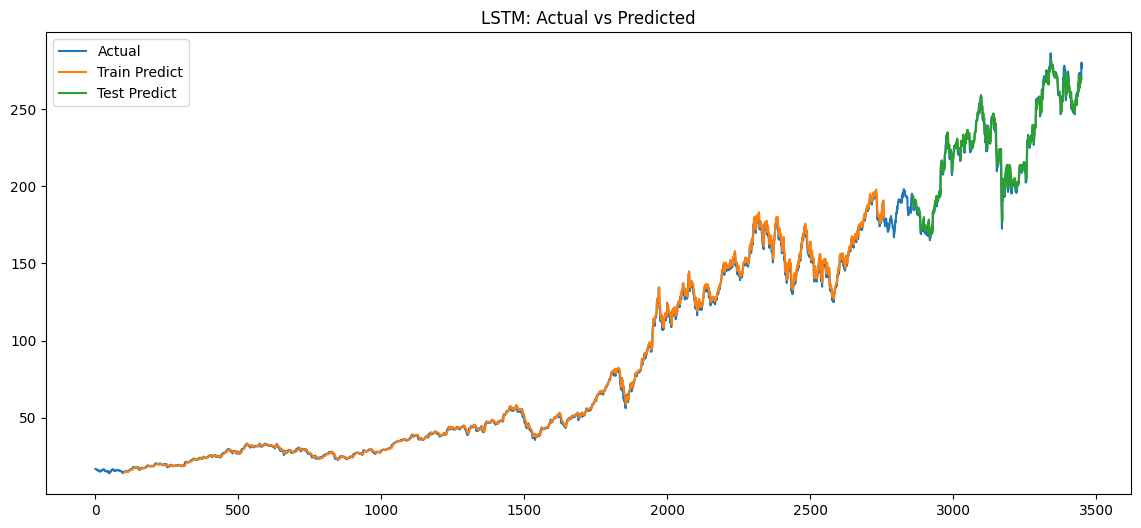

In [76]:
## Plotting
dt_values = dt.values
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(dt_values)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(dt_values)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(dt_values)-1, :] = test_predict
# plot baseline and predictions
plt.figure(figsize=(14,6))
plt.plot(dt_values, label='Actual')
plt.plot(trainPredictPlot, label='Train Predict')
plt.plot(testPredictPlot, label='Test Predict')
plt.legend()
plt.title('LSTM: Actual vs Predicted')
plt.show()

**Now Model GRU**

In [77]:
model = Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(100,1)))
model.add(GRU(50, return_sequences=True))
model.add(GRU(50))
model.add(Dense(1))
model.compile(loss = "mean_squared_error", optimizer = 'adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 50)        │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 50)        │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,601 (150.79 KB)

 Trainable params: 38,601 (150.79 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0112 - val_loss: 0.0016
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.9505e-04 - val_loss: 0.0035
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.1098e-04 - val_loss: 0.0028
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.9853e-04 - val_loss: 0.0025
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.7962e-04 - val_loss: 0.0029
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.7196e-04 - val_loss: 0.0023
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.6076e-04 - val_loss: 0.0015
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.5971e-04 - val_loss: 0.0024
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.5951e-04 - val_loss: 0.0025
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.4513e-04 - val_loss: 0.0014
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.5941e-04 - val_loss: 0.0020
Epoch 12/100

In [80]:
## Lets do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [81]:
len(test_predict)

589

In [82]:
# Inverse-transform the actual y values too, not just predictions
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Now recompute RMSE on matching scales
train_rmse = math.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = math.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 1.7054
Test RMSE: 4.7135


In [83]:
from sklearn.metrics import mean_absolute_error
test_mae = mean_absolute_error(y_test_actual, test_predict)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 3.6180


In [84]:
from sklearn.metrics import r2_score

print("GRU R2:", r2_score(y_test_actual, test_predict))

GRU R2: 0.9757790827010623


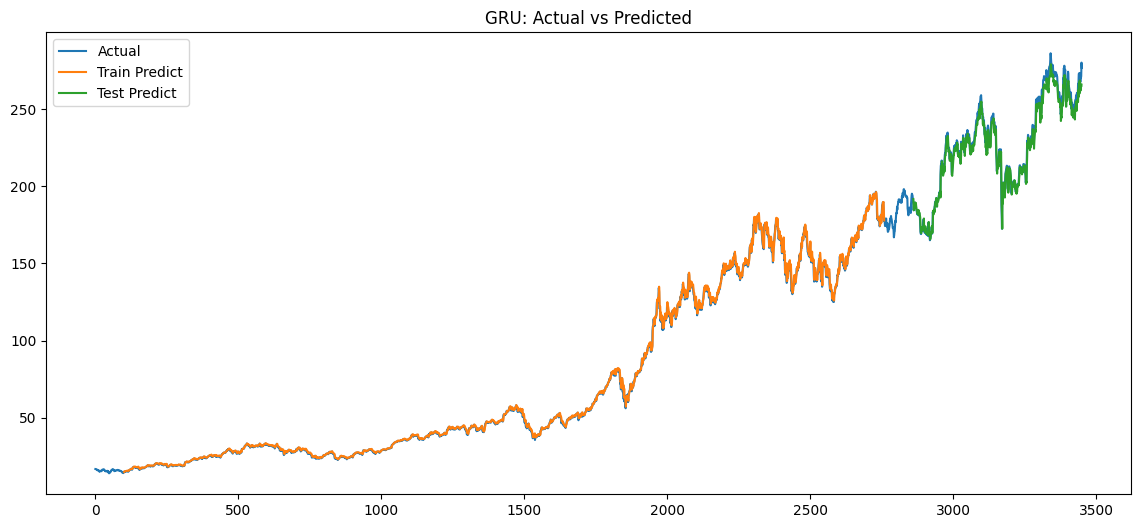

In [85]:
## Plotting
dt_values = dt.values
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(dt_values)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(dt_values)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(dt_values)-1, :] = test_predict
# plot baseline and predictions
plt.figure(figsize=(14,6))
plt.plot(dt_values, label='Actual')
plt.plot(trainPredictPlot, label='Train Predict')
plt.plot(testPredictPlot, label='Test Predict')
plt.legend()
plt.title('GRU: Actual vs Predicted')
plt.show()

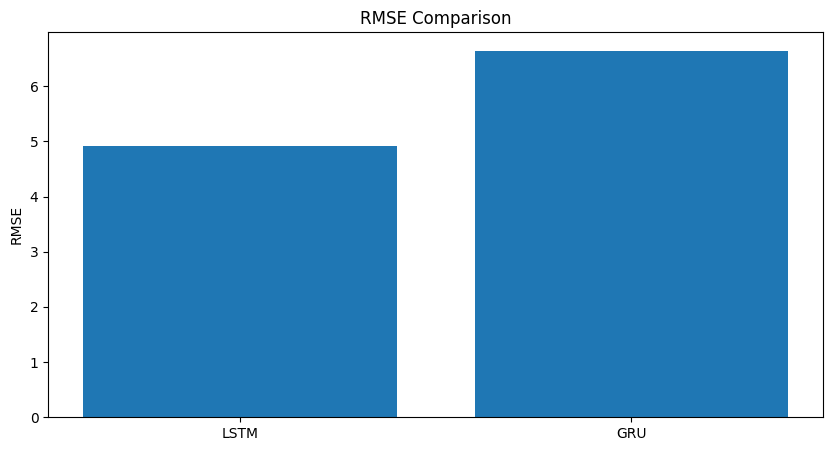

In [86]:
plt.figure(figsize=(10,5))

models = ["LSTM", "GRU"]
rmse = [4.9111, 6.6438]

plt.bar(models, rmse)

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

The performance of LSTM and GRU models was evaluated using RMSE and MAE. The LSTM model achieved a Test RMSE of 3.9313 and Test MAE of 2.7914, outperforming the GRU model, which obtained a Test RMSE of 4.7135 and Test MAE of 3.6180.

Let's quantify LSTM's improvement over GRU:

RMSE improvement ≈ 16.6%
MAE improvement ≈ 22.8%

That's a meaningful difference. This indicates that the LSTM architecture was better able to capture the temporal dependencies present in Apple stock price data.

### Best performining model is LSTM. So we will predict next 30 days using LSTM model

In [102]:
test_data

array([[0.88959059],
       [0.87813871],
       [0.88652215],
       [0.88252214],
       [0.89874113],
       [0.90476848],
       [0.8851523 ],
       [0.8766044 ],
       [0.88131667],
       [0.88838512],
       [0.86581011],
       [0.85742658],
       [0.85885128],
       [0.86170058],
       [0.87561816],
       [0.86822096],
       [0.87512503],
       [0.88197425],
       [0.89611106],
       [0.90433012],
       [0.90104246],
       [0.9087684 ],
       [0.91375466],
       [0.90356301],
       [0.90285067],
       [0.89424801],
       [0.88707003],
       [0.88498793],
       [0.87085113],
       [0.87150862],
       [0.87391956],
       [0.86109784],
       [0.83802963],
       [0.84531721],
       [0.85665948],
       [0.85928964],
       [0.87682363],
       [0.89654942],
       [0.89150832],
       [0.90564512],
       [0.91983677],
       [0.92569966],
       [0.92306958],
       [0.94493224],
       [0.93616529],
       [0.95063084],
       [0.95375404],
       [0.963

In [96]:
# Taking the last 100 observations
# These will be used as the initial sequence for forecasting

x_input = test_data[-100:].reshape(1,-1)

print(x_input.shape)

(1, 100)


In [97]:
# Converting array into a Python list
# Easier to append new predictions during forecasting

temp_input = list(x_input)

# Extract inner list
temp_input = temp_input[0].tolist()

print(len(temp_input))

100


In [98]:
temp_input

[1.4282680500722646,
 1.413090235721969,
 1.415008051148099,
 1.4231175894444654,
 1.408323204405541,
 1.4159394516122672,
 1.423884615284526,
 1.423884615284526,
 1.4216380506101818,
 1.423610713316787,
 1.419884609808159,
 1.413199763065601,
 1.413199763065601,
 1.4085424263101234,
 1.3879947622101276,
 1.361145680678945,
 1.3500225518681734,
 1.342954275814244,
 1.3447623966794235,
 1.349584275276327,
 1.3539677100640652,
 1.3479952090984113,
 1.33840629918508,
 1.3237216087071062,
 1.3237216087071062,
 1.2753386989399436,
 1.2805440904568774,
 1.2843797213091372,
 1.2826810441789305,
 1.323064110210677,
 1.3387350484332945,
 1.3287078619281167,
 1.3387898957137698,
 1.3453652151126958,
 1.4030630492167913,
 1.400158986046018,
 1.4385693057625002,
 1.4353913406239875,
 1.4475007171794025,
 1.4283228973527398,
 1.423172269507622,
 1.4331447759496432,
 1.3576938135726933,
 1.3250914529804392,
 1.3250914529804392,
 1.3694744408798938,
 1.3720497548024526,
 1.3513923961415064,
 1.373309

In [99]:
# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[1.4019936]
101
1 day input [1.41309024 1.41500805 1.42311759 1.4083232  1.41593945 1.42388462
 1.42388462 1.42163805 1.42361071 1.41988461 1.41319976 1.41319976
 1.40854243 1.38799476 1.36114568 1.35002255 1.34295428 1.3447624
 1.34958428 1.35396771 1.34799521 1.3384063  1.32372161 1.32372161
 1.2753387  1.28054409 1.28437972 1.28268104 1.32306411 1.33873505
 1.32870786 1.3387899  1.34536522 1.40306305 1.40015899 1.43856931
 1.43539134 1.44750072 1.4283229  1.42317227 1.43314478 1.35769381
 1.32509145 1.32509145 1.36947444 1.37204975 1.3513924  1.3733099
 1.38207694 1.41473415 1.42618603 1.41917243 1.37111819 1.3740771
 1.3687621  1.3620224  1.3498035  1.33429677 1.34755693 1.35276224
 1.35265271 1.32498184 1.29407816 1.30887254 1.3165984  1.29309191
 1.28772214 1.28240714 1.30158496 1.30240684 1.3077766  1.30925606
 1.28684542 1.27495519 1.31418746 1.32426958 1.32585856 1.32585856
 1.34196786 1.31259848 1.34218708 1.35089927 1.35084459 1.343831
 1.34180349 1.38344679 1.36684428 1.404

In [114]:
future_actual = scaler.inverse_transform(
    np.array(lst_output).reshape(-1,1)
)

print(future_actual[:10])

[[269.81483851]
 [263.58529275]
 [258.28553286]
 [253.57435961]
 [249.32615388]
 [245.47817141]
 [241.97815428]
 [238.78098058]
 [235.84914296]
 [233.15144335]]


In [103]:
# Creating indices for plotting

day_new = np.arange(1,101)

day_pred = np.arange(101,131)

In [105]:
len(dt)

3450

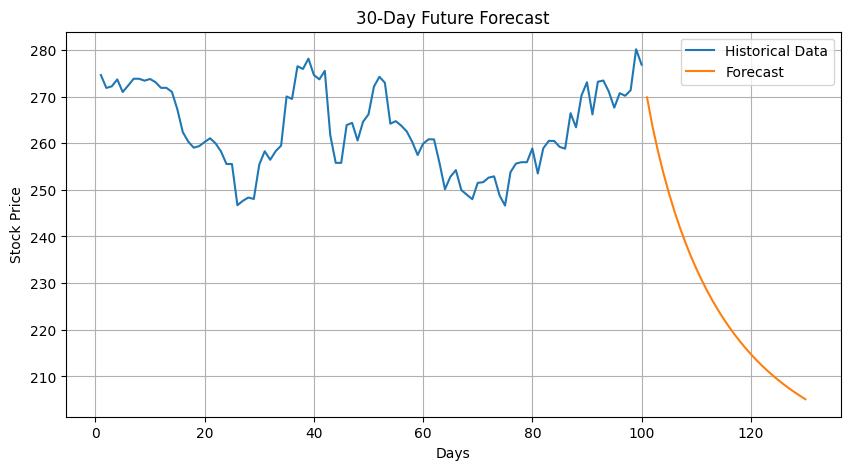

In [115]:
# Plotting:
# Blue   -> Last 100 actual observations
# Orange -> Next 30 forecasted observations

plt.figure(figsize=(10,5))

plt.plot(
    day_new,
    dt[3350:]
)

plt.plot(
    day_pred,
    scaler.inverse_transform(lst_output)
)

plt.title("30-Day Future Forecast")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.legend(["Historical Data","Forecast"])

plt.grid(True)

plt.show()

In [112]:
# Combine historical data and future predictions

dt1 = dt.values.tolist()

dt1.extend(scaler.inverse_transform(lst_output))

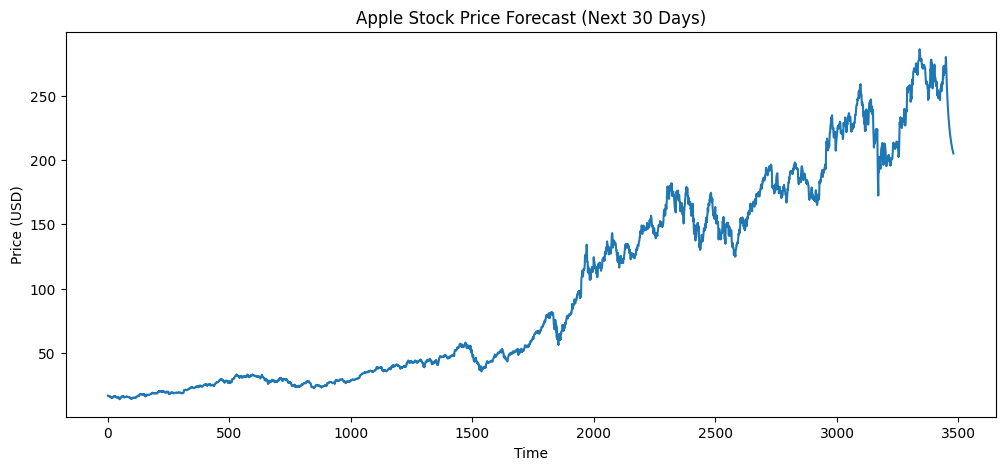

In [116]:
# Final plot in original stock price units

plt.figure(figsize=(12,5))

plt.plot(dt1)

plt.title("Apple Stock Price Forecast (Next 30 Days)")

plt.xlabel("Time")

plt.ylabel("Price (USD)")

#plt.grid(True)

plt.show()